<a href="https://colab.research.google.com/github/devyanikachare53-cmd/Python-pandas-/blob/main/assingment_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

In [ ]:
from google.colab import files

In [ ]:
uploaded = files.upload()

Saving heart - heart.csv to heart - heart.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Q1. Load the Heart Disease dataset using pandas and display the first 10 rows.
Also check the shape and basic information (info()) of the dataset.

In [ ]:
data = pd.read_csv('heart - heart.csv')

In [ ]:
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [ ]:
data.head(11)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [ ]:
data.shape

(918, 12)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Q2. Check for missing values in the dataset. Show the count of null values for
each column.

In [ ]:
data.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


Q3. Check for duplicate rows in the dataset. If any duplicates are found, remove
them and print the new shape of the dataset.

In [ ]:
duplicate_count = data.duplicated().sum()
data = data.drop_duplicates()
print("Duplicates removed.")

print("New shape of the dataset:", data.shape)

Duplicates removed.
New shape of the dataset: (918, 12)


Q4. Identify unrealistic/invalid values:
Count how many rows have Cholesterol = 0.
Count how many rows have RestingBP = 0.
Print both counts.

In [ ]:
# (data.RestingBP==0).value_counts()
chol_count = (data['Cholesterol'] == 0).sum()
bp_count = (data['RestingBP'] == 0).sum()

print("Cholesterol = 0:", chol_count)
print("RestingBP = 0:", bp_count)

Cholesterol = 0: 172
RestingBP = 0: 1


Q5. Clean the invalid values:
Replace Cholesterol = 0 with the mean cholesterol value (excluding zeros).
Replace RestingBP = 0 with the mean resting blood pressure value (excluding
zeros).
Round both columns to 2 decimal places.

Print the statistical summary (describe()) of these two columns before and after
cleaning.

In [ ]:
# Display statistics before cleaning
print("Before Cleaning:\n")

print("Cholesterol Summary:")
print(data['Cholesterol'].describe())

print("\nRestingBP Summary:")
print(data['RestingBP'].describe())


# Calculate mean excluding zero values
mean_chol = data[data['Cholesterol'] != 0]['Cholesterol'].mean()
mean_bp = data[data['RestingBP'] != 0]['RestingBP'].mean()


# Replace invalid values (0) with the calculated mean
data['Cholesterol'] = data['Cholesterol'].replace(0, mean_chol)
data['RestingBP'] = data['RestingBP'].replace(0, mean_bp)


# Round both columns to 2 decimal places
data['Cholesterol'] = data['Cholesterol'].round(2)
data['RestingBP'] = data['RestingBP'].round(2)


# Display statistics after cleaning
print("\nAfter Cleaning:\n")

print("Cholesterol Summary:")
print(data['Cholesterol'].describe())

print("\nRestingBP Summary:")
print(data['RestingBP'].describe())

Before Cleaning:

Cholesterol Summary:
count    918.000000
mean     198.799564
std      109.384145
min        0.000000
25%      173.250000
50%      223.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64

RestingBP Summary:
count    918.000000
mean     132.396514
std       18.514154
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64

After Cleaning:

Cholesterol Summary:
count    918.000000
mean     244.636253
std       53.318029
min       85.000000
25%      214.000000
50%      244.640000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64

RestingBP Summary:
count    918.000000
mean     132.540893
std       17.989932
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64


Q6. Create a function to plot histograms for the following numerical columns:
Age
RestingBP
Cholesterol
MaxHR
Plot all four histograms in one figure using subplots (2x2 layout). Use this function
to visualize the data after cleaning.

Distribution plots for all numerical columns 


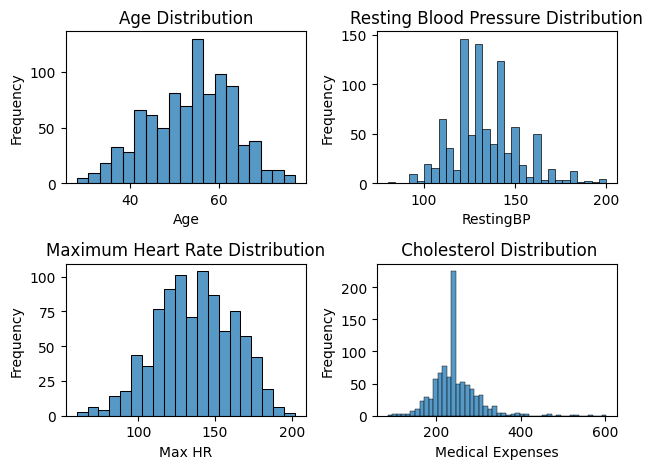

In [ ]:
print("Distribution plots for all numerical columns ")
# hist_plot=plt.hist(data["RestingBP"])

plt.subplot(2,2,1)
sns.histplot(data["Age"])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.subplot(2,2,2)
sns.histplot(data["RestingBP"])
plt.title("Resting Blood Pressure Distribution")
plt.xlabel("RestingBP")
plt.ylabel("Frequency")

plt.subplot(2,2,3)
sns.histplot(data["MaxHR"])
plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Max HR")
plt.ylabel("Frequency")



plt.subplot(2,2,4)
sns.histplot(data["Cholesterol"])
plt.title(" Cholesterol Distribution")
plt.xlabel("Medical Expenses")
plt.ylabel("Frequency")

plt.tight_layout()

Q7. Identify and print numerical columns and categorical columns separately.

In [ ]:
print("Numerical Columns")
num = data.select_dtypes(include='number')
print(num)

Numerical Columns
     Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease
0     40      140.0        289.0          0    172      0.0             0
1     49      160.0        180.0          0    156      1.0             1
2     37      130.0        283.0          0     98      0.0             0
3     48      138.0        214.0          0    108      1.5             1
4     54      150.0        195.0          0    122      0.0             0
..   ...        ...          ...        ...    ...      ...           ...
913   45      110.0        264.0          0    132      1.2             1
914   68      144.0        193.0          1    141      3.4             1
915   57      130.0        131.0          0    115      1.2             1
916   57      130.0        236.0          0    174      0.0             1
917   38      138.0        175.0          0    173      0.0             0

[918 rows x 7 columns]


In [ ]:
print("Categorical Columns ")
cat = data.select_dtypes(include='object')
print(cat)

Categorical Columns 
    Sex ChestPainType RestingECG ExerciseAngina ST_Slope
0     M           ATA     Normal              N       Up
1     F           NAP     Normal              N     Flat
2     M           ATA         ST              N       Up
3     F           ASY     Normal              Y     Flat
4     M           NAP     Normal              N       Up
..   ..           ...        ...            ...      ...
913   M            TA     Normal              N     Flat
914   M           ASY     Normal              N     Flat
915   M           ASY     Normal              Y     Flat
916   F           ATA        LVH              N     Flat
917   M           NAP     Normal              N       Up

[918 rows x 5 columns]


Q8. Perform One-Hot Encoding on all categorical columns using
pd.get_dummies().
Store the result in a new dataframe called df_encoded.
Print the shape and the first 5 rows of the encoded dataframe.


In [ ]:
df_encoded = pd.get_dummies(data)


In [ ]:
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


Q9. After cleaning and encoding:
Print the final shape of df_encoded.
Show the list of all column names in the final dataframe.

In [ ]:
df_encoded.shape

(918, 21)

In [ ]:
df_encoded.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

Q10. (Summary)
Write a short summary (in comments or markdown) covering:
1. What invalid values did you find and how did you fix them?

ans : The dataset contained invalid values where Cholesterol = 0 and RestingBP = 0.
 These values were replaced with the mean of the valid (non-zero) values.  

2. Why is it important to handle invalid values like Cholesterol = 0?

ans : Cholesterol can't be zero in real life. These wrong zeros make our data and predictions inaccurate, so we replace them with a more realistic average.

3. What is the purpose of One-Hot Encoding?

ans : The purpose of One-Hot Encoding is to convert categorical variables into a numerical format that machine learning algorithms can process. By creating binary columns for each category, it prevents the algorithm from assuming an ordinal relationship between categories, which would be incorrect for nominal data.

4. Any other observations from the cleaning process.

ans : During the cleaning process, it was observed that Cholesterol had a high number of zero values (172 rows), while RestingBP had only one zero value. Replacing these values with the mean of non-zero entries led to a more realistic distribution for both features. The duplicate check revealed no duplicate rows. After one-hot encoding, the dataset's column count increased from 12 to 21, reflecting the conversion of categorical features into multiple binary columns.